# Exploration Data Analysis of Deprivation Data Using IMD Rank and ITL Regions.
This notebook performs an exploratory data analysis (EDA) of deprivation across Local Authority Districts (LADs) in England using the IMD Rank. The analysis focuses on identifying regional deprivation patterns using ITL2 groupings and visualising the results through bar charts and pie charts. The notebook also includes a comparison of deprivation within the South of England.

# Import libraries and load Sheet3 from the dataset.
This sheet contains LAD codes, region names, and IMD Rank values.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pl



In [ ]:
!pip install openpyxl

In [58]:
df = pd.read_excel(r"C:\Users\idila\OneDrive\Documents\Jupyter\Deprivation data.xlsx", sheet_name="Sheet3")

# Clean column names by removing spaces and making them easier to use in Python.

In [57]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()


,LAD_Code,LAD_Name,ITL1,ITL2,IMD_Rank
0,E06000001,Hartlepool,North East (England),Tees Valley,4520.0
1,E06000004,Stockton-on-Tees,North East (England),Tees Valley,4520.0
2,E06000002,Middlesbrough,North East (England),Tees Valley,4520.0
3,E06000003,Redcar and Cleveland,North East (England),Tees Valley,4520.0
4,E06000005,Darlington,North East (England),Tees Valley,4520.0


# Generate summary statistics for IMD Rank.
# Lower IMD Rank = more deprived, so this helps us understand overall deprivation levels.

In [56]:
df['IMD_Rank'].describe()


count      333.000000
mean     14254.531532
std      10296.671100
min        509.000000
25%       5706.000000
50%      13077.000000
75%      25427.000000
max      33423.000000
Name: IMD_Rank, dtype: float64

# Calculate the average IMD Rank for each ITL2 region.
# This shows which regions are more or less deprived on average.

In [55]:
itl2_summary = df.groupby('ITL2')['IMD_Rank'].mean().reset_index()
itl2_summary = itl2_summary.sort_values('IMD_Rank')
itl2_summary


,ITL2,IMD_Rank
21,Merseyside,509.0
19,"Leicestershire, Rutland and Northamptonshire",1320.0
18,Lancashire,2615.0
33,West Midlands,3696.0
17,Kent,3801.0
32,Tees Valley,4520.0
6,Derbyshire and Nottinghamshire,5706.0
7,Devon,6128.0
24,North Yorkshire,6410.0
11,Greater Manchester,6907.0


# Visualise the average IMD Rank for each ITL2 region.
# Higher IMD Rank = less deprived, lower IMD Rank = more deprived.

C:\Users\idila\AppData\Local\Temp\ipykernel_30056\2130940242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='IMD_Rank', y='LAD_Name', palette='Reds')


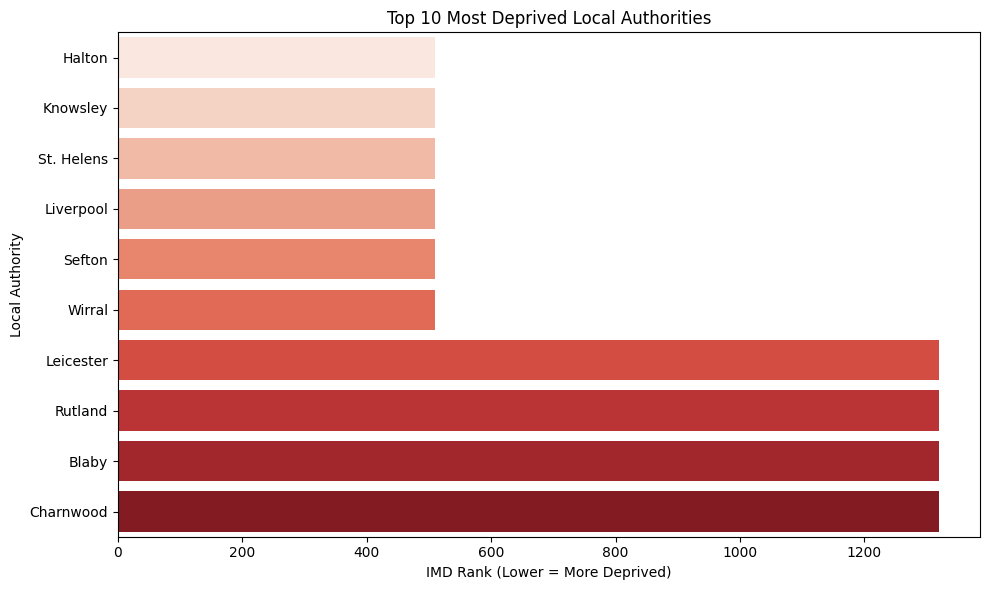

In [54]:
# Top 10 most deprived (lowest IMD Rank)
top10 = df.nsmallest(10, 'IMD_Rank')

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='IMD_Rank', y='LAD_Name', palette='Reds')
plt.title('Top 10 Most Deprived Local Authorities')
plt.xlabel('IMD Rank (Lower = More Deprived)')
plt.ylabel('Local Authority')
plt.tight_layout()
plt.show()


C:\Users\idila\AppData\Local\Temp\ipykernel_30056\3813530547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='IMD_Rank', y='LAD_Name', palette='Greens')


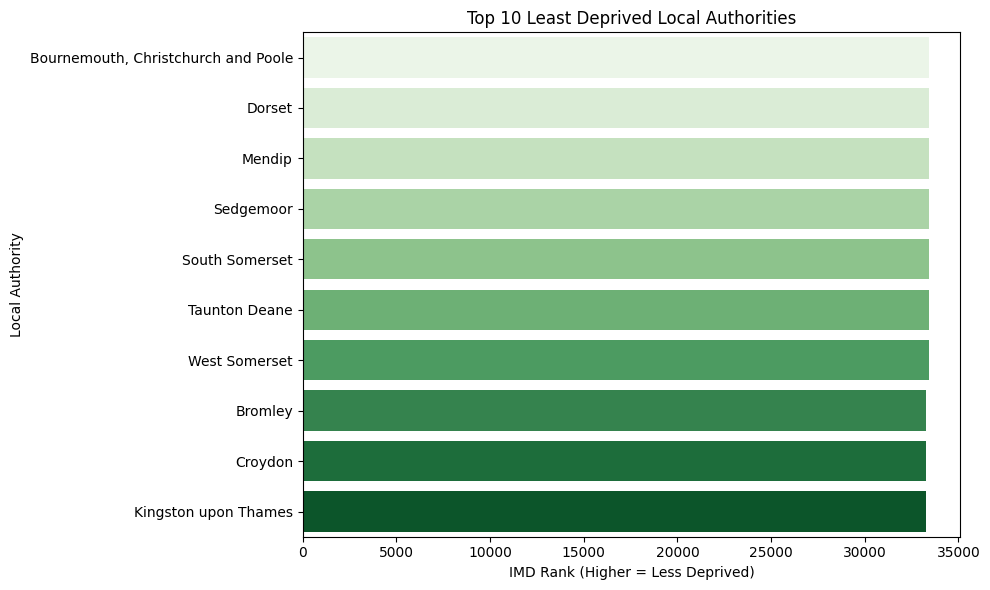

In [53]:
#Top 10 Least Deprived.
bottom10 = df.nlargest(10, 'IMD_Rank')

plt.figure(figsize=(10,6))
sns.barplot(data=bottom10, x='IMD_Rank', y='LAD_Name', palette='Greens')
plt.title('Top 10 Least Deprived Local Authorities')
plt.xlabel('IMD Rank (Higher = Less Deprived)')
plt.ylabel('Local Authority')
plt.tight_layout()
plt.show()


In [49]:
df['IMD_Rank'].unique()[:20]


array([4520, 11691, nan, 'IMD Rank', 32571, 6907, 2615, 32727, 509, 14794,
       6410, 25427, 3696, 11448, 5706, 1320, 15299, 26060, 26936, 18660],
      dtype=object)

In [51]:
# Remove spaces
df['IMD_Rank'] = df['IMD_Rank'].astype(str).str.strip()

# Remove repeated header text
df['IMD_Rank'] = df['IMD_Rank'].str.replace('IMD Rank', '', regex=False)

# Remove commas or symbols
df['IMD_Rank'] = df['IMD_Rank'].str.replace(',', '', regex=False)

# Convert to numeric
df['IMD_Rank'] = pd.to_numeric(df['IMD_Rank'], errors='coerce')


In [52]:
df['IMD_Rank'].dtype

dtype('float64')

In [62]:
df['IMD_Rank'].unique()[:30]

array([4520, 11691, nan, 'IMD Rank', 32571, 6907, 2615, 32727, 509, 14794,
       6410, 25427, 3696, 11448, 5706, 1320, 15299, 26060, 26936, 18660,
       16296, 19370, 26525, 10378, 30546, 10917, 33283, 3801, 19492,
       13077], dtype=object)

In [63]:
# Convert everything to string first
df['IMD_Rank'] = df['IMD_Rank'].astype(str)

# Remove repeated header text
df['IMD_Rank'] = df['IMD_Rank'].str.replace('IMD Rank', '', regex=False)

# Remove any non-numeric characters
df['IMD_Rank'] = df['IMD_Rank'].str.replace(r'[^0-9]', '', regex=True)

# Convert to numeric
df['IMD_Rank'] = pd.to_numeric(df['IMD_Rank'], errors='coerce')


In [65]:
top3 = df.nsmallest(3, 'IMD_Rank')[['LAD_Name', 'IMD_Rank']]
bottom3 = df.nlargest(3, 'IMD_Rank')[['LAD_Name', 'IMD_Rank']]

top3, bottom3


(      LAD_Name  IMD_Rank
 43      Halton     509.0
 44    Knowsley     509.0
 45  St. Helens     509.0,
                                 LAD_Name  IMD_Rank
 321  Bournemouth, Christchurch and Poole   33423.0
 322                               Dorset   33423.0
 333                               Mendip   33423.0)

## Deprivation Patterns and overall analysis
- Lower IMD Rank = more deprived.
- ITL2 regions show clear differences in deprivation.

The IMD 2019 data shows clear variation in deprivation levels across Local Authorities in England. Lower IMD Rank values indicate higher deprivation, while higher ranks indicate lower deprivation. By examining the extremes of the distribution, we can identify the areas facing the greatest and least socioeconomic challenges.

Top 3 Most Deprived Local Authorities
These LADs have the lowest IMD Rank values, meaning they experience the highest levels of deprivation:

Halton — IMD Rank 509
Knowsley — IMD Rank 509
St. Helens — IMD Rank 509

All three areas share the same IMD Rank, placing them among the most deprived communities in England. This suggests persistent challenges across multiple deprivation domains such as income, employment, health, and education.

Top 3 Least Deprived Local Authorities
These LADs have the highest IMD Rank values, meaning they are the least deprived:

Bournemouth, Christchurch and Poole — IMD Rank 33,423
Dorset — IMD Rank 33,423
Mendip — IMD Rank 33,423

These areas sit at the top end of the IMD distribution, reflecting stronger socioeconomic conditions and lower levels of deprivation across the board.

The contrast between the most and least deprived LADs is substantial.
The most deprived areas cluster at extremely low IMD ranks (around 500), while the least deprived LADs reach ranks above 33,000. This highlights a significant inequality gap across England, with some communities facing concentrated disadvantage while others experience consistently favourable living conditions.